# Machine Learning Notes

This file contains notes for machine learning.

## Features and Labels

- **Features** are the inputs provided to the machine for processing.
- **Labels** are the outputs given by the machine after processing features.

---

## Supervised and Unsupervised learning

- **Supervised Learning** is the term used for the data which is already processed by the machine or in other words, something that machine knows before hand. Feature and labels are already present on the data. It contains:-

  - **Classification** : It refers to the mode where model performs classification on the basis of pre-defined labels.

  - **Regression** : It refers to prediction of values on basis of historical data.

- **Unsupervised learning** is the term used for the data which is new for the machine. Neither it has any features or labels present on it nor the machine is trained for it. It contains:-

  - **Clustering** : When the model is asked to perform classification on the basis of features only.

---

We'll use **Python** for machine learning since it has already developed libraries like ***scikit-learn(sklearn)***

---

Most of the material in this file is incorporated from [Microsoft Learn repository](https://github.com/MicrosoftDocs/ml-basics/)

Machine Learning requires data on which it can operate. For notes,we're using the [Flights Challenge](/assets/flights.csv)'s data.

In [3]:
# Importing Libraries
import pandas as pd
import matplotlib.pyplot as mp

To import a .csv file, we use **`read_csv("filepath")`** function of *Pandas* library. It returns a dataframe which has values imported from csv file.

In [4]:
data = pd.read_csv("d:/Projects/ML/assets/flights.csv")
data.head()

,Year,Month,DayofMonth,DayOfWeek,Carrier,OriginAirportID,OriginAirportName,OriginCity,OriginState,DestAirportID,DestAirportName,DestCity,DestState,CRSDepTime,DepDelay,DepDel15,CRSArrTime,ArrDelay,ArrDel15,Cancelled
0,2013,9,16,1,DL,15304,Tampa International,Tampa,FL,12478,John F. Kennedy International,New York,NY,1539,4,0.0,1824,13,0,0
1,2013,9,23,1,WN,14122,Pittsburgh International,Pittsburgh,PA,13232,Chicago Midway International,Chicago,IL,710,3,0.0,740,22,1,0
2,2013,9,7,6,AS,14747,Seattle/Tacoma International,Seattle,WA,11278,Ronald Reagan Washington National,Washington,DC,810,-3,0.0,1614,-7,0,0
3,2013,7,22,1,OO,13930,Chicago O'Hare International,Chicago,IL,11042,Cleveland-Hopkins International,Cleveland,OH,804,35,1.0,1027,33,1,0
4,2013,5,16,4,DL,13931,Norfolk International,Norfolk,VA,10397,Hartsfield-Jackson Atlanta International,Atlanta,GA,545,-1,0.0,728,-9,0,0


## Data Analysis
### Data Cleaning - Handling null values
Now we have our data, the first step is to clean data. <br>Data can be cleaned in two steps:
1. **Fill null values** - We can fill up the null values in our data with the values of our wish.
Firstly let's check for null values:

In [5]:
data.isnull().sum()

Year                    0
Month                   0
DayofMonth              0
DayOfWeek               0
Carrier                 0
OriginAirportID         0
OriginAirportName       0
OriginCity              0
OriginState             0
DestAirportID           0
DestAirportName         0
DestCity                0
DestState               0
CRSDepTime              0
DepDelay                0
DepDel15             2761
CRSArrTime              0
ArrDelay                0
ArrDel15                0
Cancelled               0
dtype: int64

To fill this data:<br>We use **`fillna(value_to_be_filled_with)`** function.

In [6]:
# I have commented the line since I don't prefer filling null values.
# data.DepDel15 = data.DepDel15.fillna(data.DepDel15.mean())

2. **Removing null values** *(which I prefer)* - We can remove the null values present in our data. In most cases, it's better to remove null values and train our model on the data which is absolutely correct. This also improves its *MSE* and *RMSE*.<br>
To remove the null values from ***DepDel15*** column,<br>We use **`dropna(axis=?,how=?)`**

In [7]:
data = data.dropna(axis=0,how='any')
data.isnull().sum()

Year                 0
Month                0
DayofMonth           0
DayOfWeek            0
Carrier              0
OriginAirportID      0
OriginAirportName    0
OriginCity           0
OriginState          0
DestAirportID        0
DestAirportName      0
DestCity             0
DestState            0
CRSDepTime           0
DepDelay             0
DepDel15             0
CRSArrTime           0
ArrDelay             0
ArrDel15             0
Cancelled            0
dtype: int64

### Outlier Handling<br>

Now that we have cleaned our data, next step is to remove outliers. For that we first have to determine the distribution and its density.

---
For determinig distribution, we have to use our ***matplotlib.pyplot*** library.

In [8]:
# We'll define a function for viewing distribution
def distribution(var):
    import matplotlib.pyplot as mp
    %matplotlib inline
    mean = var.mean()
    median = var.median()
    mode = var.mode()[0]
    max = var.max()
    min = var.min()
    print("Mean : {0}\nMedian: {1}\nMode: {2}\nMin: {3}\nMax: {4}".format(mean,median,mode,min,max))
    fig,ax = mp.subplots(2, 1,figsize=(9,6))
    ax[0].hist(x=var)
    ax[0].axvline(x=mean, color='red',linewidth=3)
    ax[0].axvline(x=median, color='green',linewidth=3)
    ax[0].axvline(x=mode, color='black',linewidth=3)
    ax[0].axvline(x=min, color='yellow',linewidth=3)
    ax[0].axvline(x=max, color='purple',linewidth=3)

    ax[1] = mp.boxplot(x=var,vert=False)
    fig.suptitle("Distribution of data")
    fig.show(warn=False)

The **Distribution** function will help us determine the distribution of the variable provided to it.
Its explaination is given below:
1. First we import the **`matplotlib.pyplot`** library. The `%matplotlib imline` statement aligns the plots inline in the notebook.
2. Then we assign variables to the statistical data of our variable like *mean, median, mode, etc.* and print them for further usage. The `format()` function allows us to interpolate variable between the string.
3. After that, we create a figure with 1 row and 2 columns and name it as *fig* and assign its axes to *ax*.
4. On the first column, we create a histogram and plot mean, median,mode on it. The `axvline()` function plots a 2D line on the graph.
5. Then on the 2nd column, we will plot a boxplot graph. A boxplot graph is useful for determining outliers as it creates a circle on the values which occur outside the usual ones.
6. After plotting graphs, we wil use `suptitle` to title our graphs and `show` function to save our graphs.

---

Now that we have created our function, we will now see the distribution of **DepDelay** column

Mean : 10.456614371849216
Median: -1.0
Mode: -3
Min: -63
Max: 1425


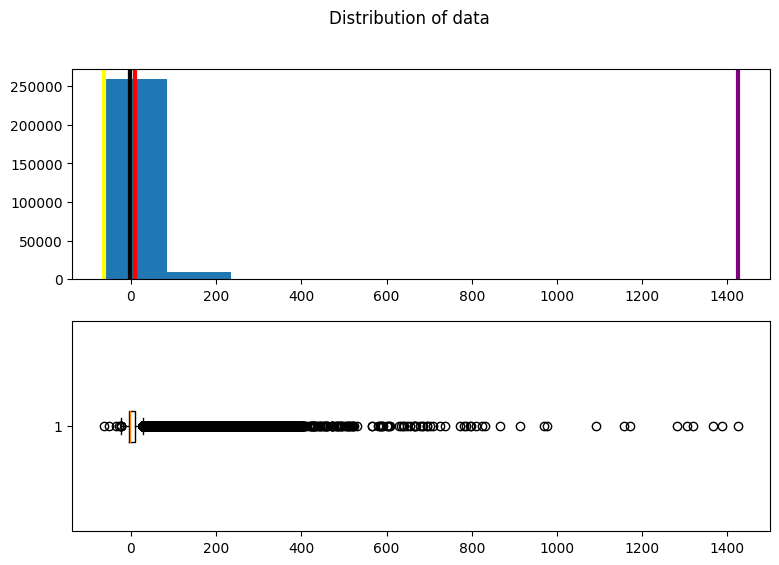

In [9]:
Dep_delay = data['DepDelay']
distribution(Dep_delay)

**Removing Outliers** - 
This data is quite uneven according to our histogram and it also has a good number of outliers according to our boxplot graph. So, let's start removing them.<br>
We'll use the `quantile` function of *pandas* library to remove our outliers.

Mean : 2.455424304018821
Median: -1.0
Mode: -3
Min: -7
Max: 37


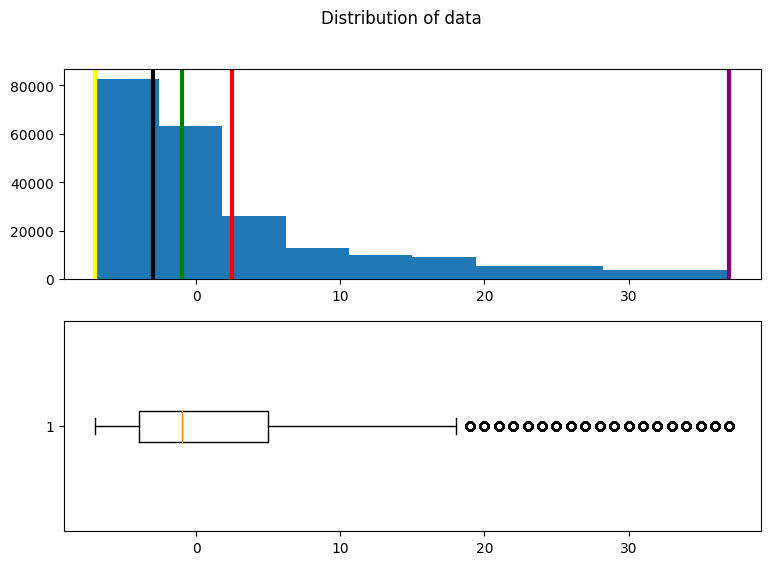

In [10]:
Dep_out = Dep_delay.quantile(0.9)
Dep_in = Dep_delay.quantile(0.1)
Dep_delay = Dep_delay[Dep_delay.between(Dep_in, Dep_out)]
distribution(Dep_delay)

**`Quantile`** function helps us to remove outliers present in our data. In the previous cell,On the line 1,I added the quantile function with a parameter of 0.9 which take the values above the 90% and assigns it to a variable **Dep_out**. On the 2nd line, I added the quantile function with the parameter of 0.1 which takes the values below 10% and assigns it to a variable **Dep_in**.

---

Now that the *DepDelay* column is clean, let's start cleaning *ArrDelay* column.

In [11]:
Arr_Delay = data['ArrDelay']
Arr_out = Arr_Delay.quantile(0.9)
Arr_in = Arr_Delay.quantile(0.1)
Arr_Delay = Arr_Delay[Arr_Delay.between(Arr_out,Arr_in)]

We have cleared ***Arr_Delay*** and ***Dep_Delay*** columns which are our labels on which we'll be building our models.

---

### Density Plot

Another way of visualizing data is by plotting its density. *Pandas* library has a useful and effective way to do this.

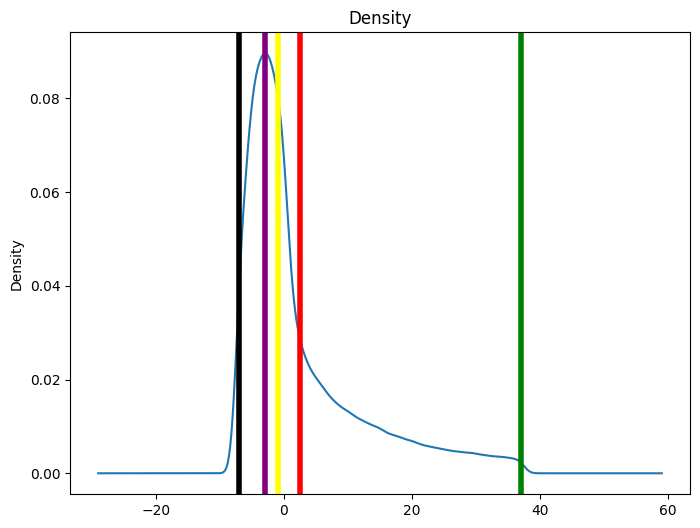

In [12]:
def density(var):
    import matplotlib.pyplot as mp
    fig = mp.figure(figsize=(8,6)) # Figure function is same as subplots but it creates only a single figure
    var.plot.density() # Plotting density
    mp.title("Density")
    mean = var.mean()
    median = var.median()
    mode = var.mode()[0]
    max = var.max()
    min = var.min()
    mp.axvline(x=mean,color='red',linewidth=4)
    mp.axvline(x=median,color='yellow',linewidth=4)
    mp.axvline(x=max,color='green',linewidth=4)
    mp.axvline(x=min,color='black',linewidth=4)
    mp.axvline(x=mode,color='purple',linewidth=4)
    mp.show()

density(Dep_delay)

### Standard Deviation and Variance

Variance is an important concept in statistical analysis of data. In python, there are pre-defined functions which help us calculate the standard and mean deviation of our data.

---

**Standard and Mean deviation** - What is the difference?
While they both tell the deviation of data from its mean, their calculation is a bit different.

*The **mean deviation** is calculated by subtracting mean from each value and taking average of the difference, while **standard deviation** is calculated by the root of **variance** which in turn is calculated by the squared difference between mean and values.*

Since *standard deviation* uses squared values, it is more sensitive to **outliers**.

---

**Calculating variance and standard deviation in *Python***

In [13]:
std = Dep_delay.std()
var = Dep_delay.var()
print("Standard deviation: {0}\nVariance: {1}\n".format(std,var))

Standard deviation: 9.555299888938341
Variance: 91.30375596754507



We can also use **`describe`** function. It is a more useful function as it provides all the useful information required to analyze our data.

In [14]:
data.describe(exclude=[object])
#exclude argument takes a list of types which should not be included while calculating mean,variance,etc.

,Year,Month,DayofMonth,DayOfWeek,OriginAirportID,DestAirportID,CRSDepTime,DepDelay,DepDel15,CRSArrTime,ArrDelay,ArrDel15,Cancelled
count,269179.0,269179.000000,269179.000000,269179.000000,269179.000000,269179.000000,269179.000000,269179.000000,269179.000000,269179.000000,269179.000000,269179.000000,269179.000000
mean,2013.0,6.983877,15.817259,3.902336,12744.767642,12739.446093,1324.412933,10.456614,0.201134,1504.637338,6.563287,0.207888,0.000576
std,0.0,1.983873,8.805963,1.989296,1501.949045,1503.506863,470.760511,35.840715,0.400849,493.215438,38.420207,0.405797,0.023989
min,2013.0,4.000000,1.000000,1.000000,10140.000000,10140.000000,1.000000,-63.000000,0.000000,1.000000,-75.000000,0.000000,0.000000
25%,2013.0,5.000000,8.000000,2.000000,11292.000000,11292.000000,920.000000,-4.000000,0.000000,1119.000000,-11.000000,0.000000,0.000000
50%,2013.0,7.000000,16.000000,4.000000,12892.000000,12892.000000,1319.000000,-1.000000,0.000000,1527.000000,-3.000000,0.000000,0.000000
75%,2013.0,9.000000,23.000000,6.000000,14057.000000,14057.000000,1722.000000,9.000000,0.000000,1917.000000,10.000000,0.000000,0.000000
max,2013.0,10.000000,31.000000,7.000000,15376.000000,15376.000000,2359.000000,1425.000000,1.000000,2359.000000,1440.000000,1.000000,1.000000


With this, We Complete our Data Analysis part. But it is hard to maintain low ***MSE*** and ***RMSE*** without normalizing it. So, let's start normalizing our data.

---

### Normalizing Data

It is important to normalize data especially numeric values so that they are always measured on the same scale. This helps our model to easily find out *correlation* between them. For this, we are going to use **sklearn** Library.

Our columns of interest(*ArrDelay* and *DepDelay*) are already normalized, so we don't need to change it. So
we'll leave it as it is.

In [15]:
# from sklearn.preprocessing import MinMaxScaler

# Get a scaler object
# scaler = MinMaxScaler()

# Create a new dataframe for the scaled values
# df_normalized = df_sample[['Name', 'Grade', 'StudyHours']].copy()

# Normalize the numeric columns
# df_normalized[['Grade','StudyHours']] = scaler.fit_transform(df_normalized[['Grade','StudyHours']])

# Plot the normalized values
# df_normalized.plot(x='Name', y=['Grade','StudyHours'], kind='bar', figsize=(8,5))

### Finding Correlation

Let's find correlation betweeen our data by using **`corr()`** function.

In [16]:
data.DepDelay.corr(data.ArrDelay)

0.9388604387910373

Correlation is a statistic value that shows the *strength of relationship* between two data. its value is b/w 1 & -1. In our case, the **corr()** function returns a value of 0.94 (approx) which means that *DepDelay* and *ArrDelay* have a strong relationship.
> WARNING: data scientist often use quote - ***correlation is not the causation*** which means here that high correlation value does not indicate higher departure delays have high arrival delays or vice versa.

---

***Visualising Correlation***:<br>
we can use a scatter plot to demonstrate the correlation between our data.

<Axes: xlabel='DepDelay', ylabel='ArrDelay'>

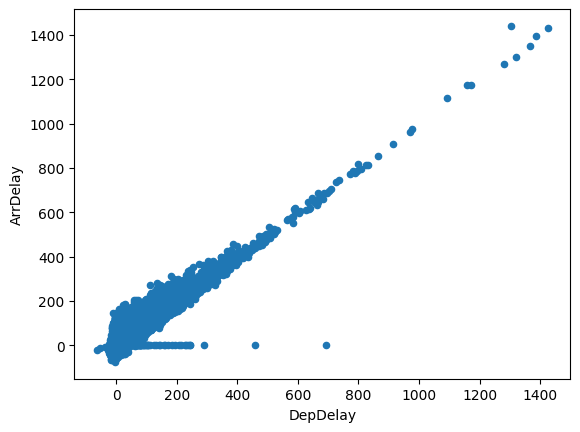

In [17]:
data.plot.scatter(x='DepDelay', y='ArrDelay')

## Regression

Till now whatever we've done is Data Analysis. But now, we take a step forward and start learning about traning and evaluating Regression models.
For that we'll move step by step.

1. Find out what label is to be predicted
2. Separate features into numeric and categorical features
3. Split training and testing data
4. Train and Evaluate the model
6. Test model using different algorithms

The data we used till now is perfect for data analysis but is not suitable for Regression models, so we use a different data i.e. [Auto MPG](https://archive.ics.uci.edu/dataset/9/auto+mpg)

Since we have a new dataset, we'll need to analyze it first.

---

In [18]:
# Importing Data
import pandas as pd
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data"
columns = ["mpg", "cylinders", "displacement", "horsepower", "weight", "acceleration", "model year", "origin", "car name"]
dt = {'mpg': float, 'cylinders': int, 'displacement': float, 'weight': float, 'acceleration': float, 'model year': int, 'origin': int}
df = pd.read_csv(url, sep="\s+", names=columns, dtype=dt)
print(df.head())
print(df.describe())

    mpg  cylinders  displacement horsepower  weight  acceleration  model year  \
0  18.0          8         307.0      130.0  3504.0          12.0          70   
1  15.0          8         350.0      165.0  3693.0          11.5          70   
2  18.0          8         318.0      150.0  3436.0          11.0          70   
3  16.0          8         304.0      150.0  3433.0          12.0          70   
4  17.0          8         302.0      140.0  3449.0          10.5          70   

   origin                   car name  
0       1  chevrolet chevelle malibu  
1       1          buick skylark 320  
2       1         plymouth satellite  
3       1              amc rebel sst  
4       1                ford torino  
              mpg   cylinders  displacement       weight  acceleration  \
count  398.000000  398.000000    398.000000   398.000000    398.000000   
mean    23.514573    5.454774    193.425879  2970.424623     15.568090   
std      7.815984    1.701004    104.269838   846.841774 

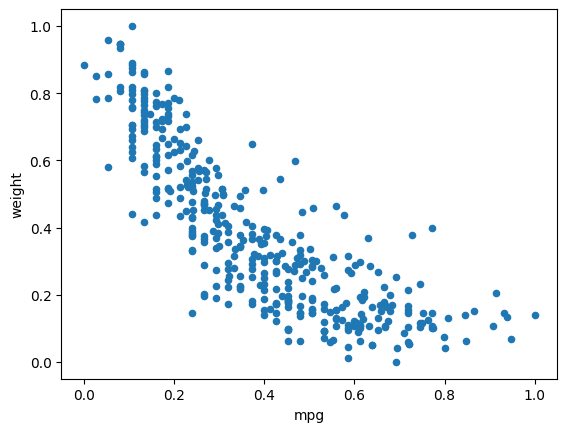

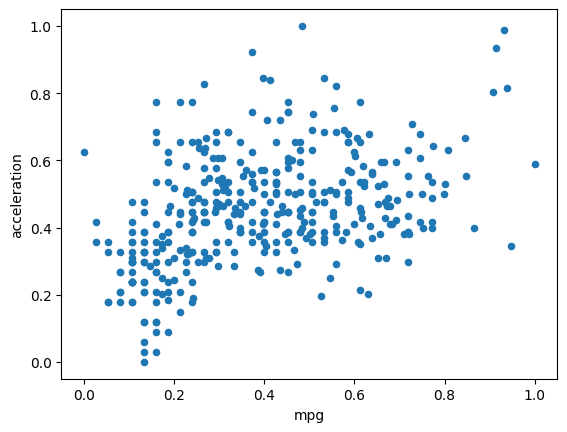

In [19]:
# It doesn't have any null value, so we'll skip this step
# distribution() shows that there is no outlier in the data, so that step is also skipped
# But we'll have to normalize our data, so...
from sklearn.preprocessing import MinMaxScaler
sc = MinMaxScaler()
df[['mpg','weight','acceleration']] = sc.fit_transform(df[['mpg','weight','acceleration']])
# Our data is also normalized, let's see its distribution over MPG
y=['weight', 'acceleration']
for i in y:
    df.plot.scatter(x='mpg',y=i)

Now, let's start creating and training a regression model.

---

### Find out which label is to be predicted

In the Auto-MPG data, it is already given that we have to train a model which predicts values for **MPG** column.

---

Let's see our label's distribution-

Mean : 0.38602587405110655
Median: 0.3723404255319148
Mode: 0.10638297872340427
Min: 0.0
Max: 1.0000000000000002


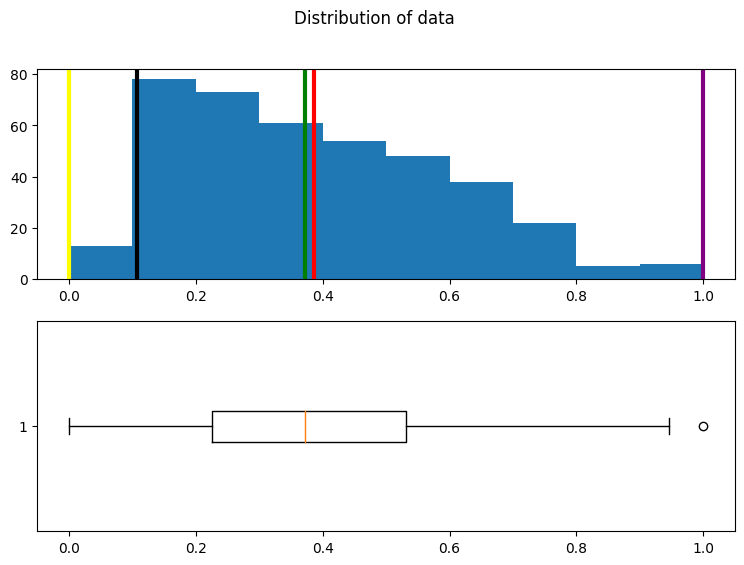

In [20]:
label = df['mpg']
distribution(label)

### Separate features into numeric and categorical

For this, first we have to make sure what columns are features, by looking into the columns, it is easy to note that *car name* column is useless. A simple way of determining which columns are numeric feature and which are categorical is to check their data type. 

In [21]:
df.dtypes

mpg             float64
cylinders         int32
displacement    float64
horsepower       object
weight          float64
acceleration    float64
model year        int32
origin            int32
car name         object
dtype: object

Usually, categorical features are of **object** dtype and numeric of **float** or **int**, but here, columns have a disrupted dtype. So, we'll classify them as per they should be.

In [22]:
cf = ['model year', 'origin','cylinders']
nf = ['displacement','weight','acceleration']

As we have separated out numeric and categorical features, let's see how they are distributed-

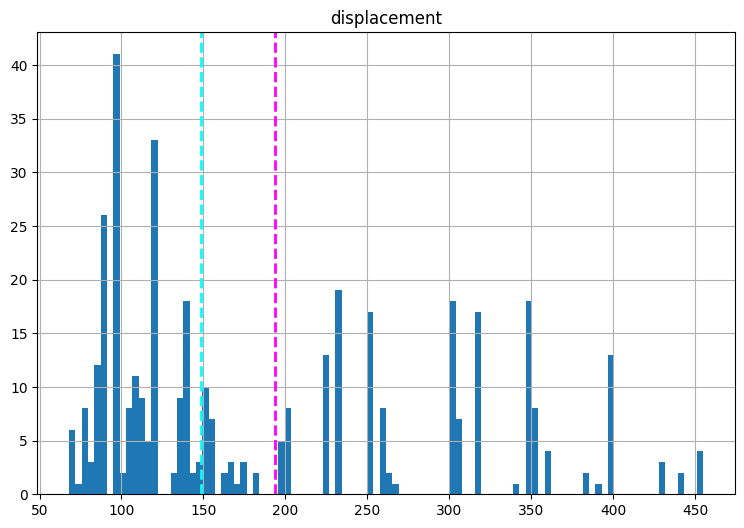

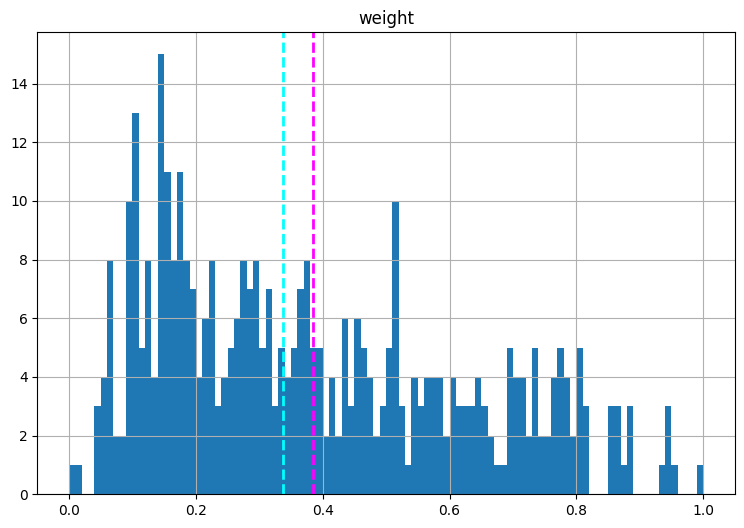

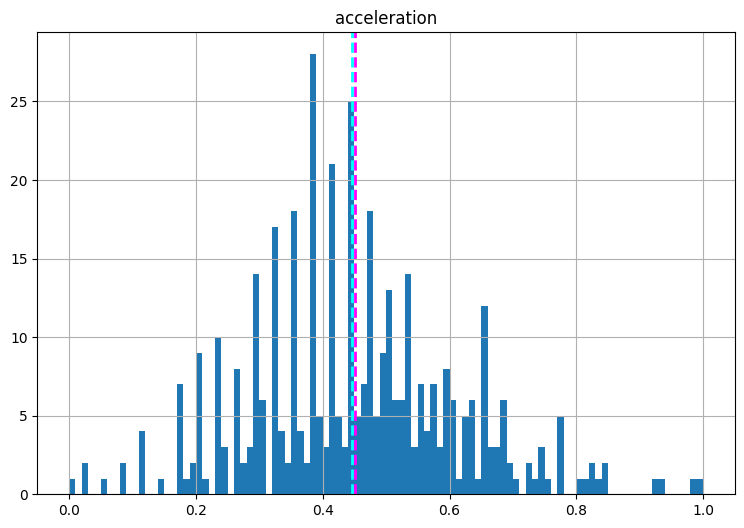

In [23]:
for col in nf:
    fig = mp.figure(figsize=(9, 6))
    ax = fig.gca()
    feature = df[col]
    feature.hist(bins=100, ax = ax)
    ax.axvline(feature.mean(), color='magenta', linestyle='dashed', linewidth=2)
    ax.axvline(feature.median(), color='cyan', linestyle='dashed', linewidth=2)
    ax.set_title(col)
mp.show()

Now let's explore the distribution of categorical features-

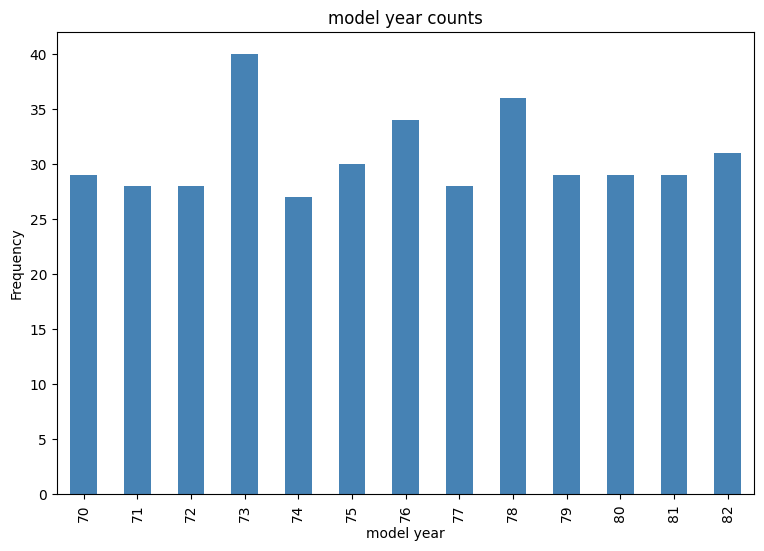

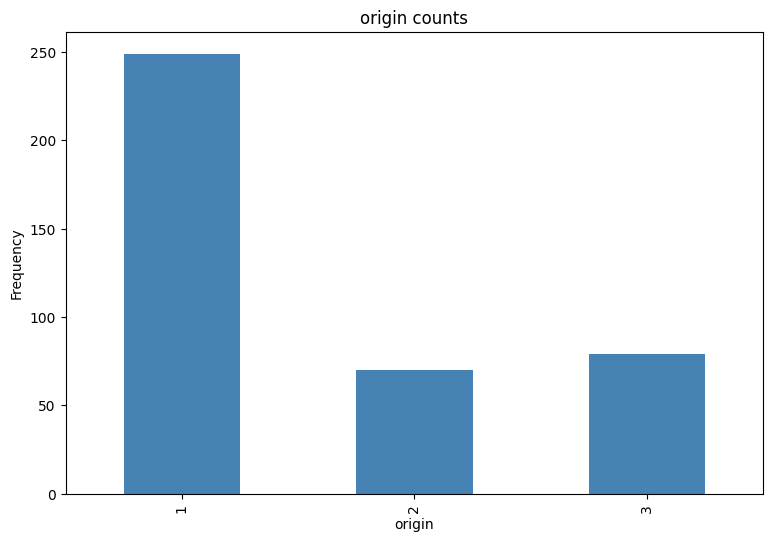

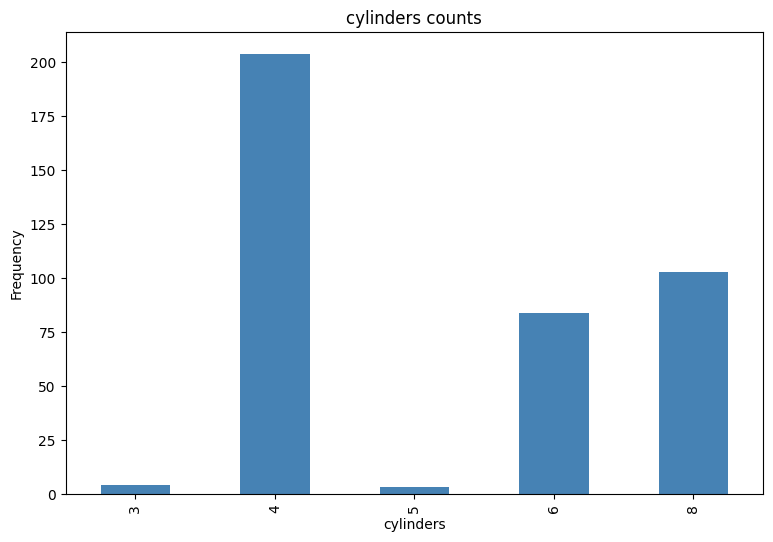

In [24]:
for col in cf:
    counts = df[col].value_counts().sort_index()
    fig = mp.figure(figsize=(9, 6))
    ax = fig.gca()
    counts.plot.bar(ax = ax, color='steelblue')
    ax.set_title(col + ' counts')
    ax.set_xlabel(col) 
    ax.set_ylabel("Frequency")
mp.show()


Checking features' relation with our label-

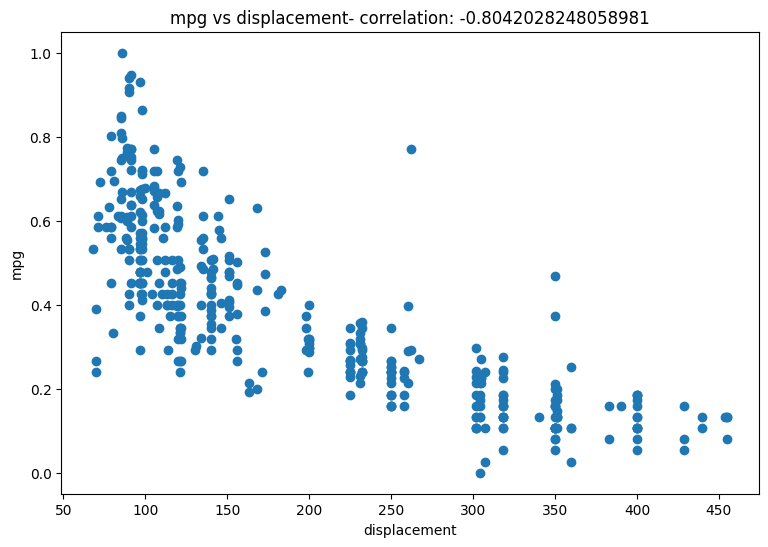

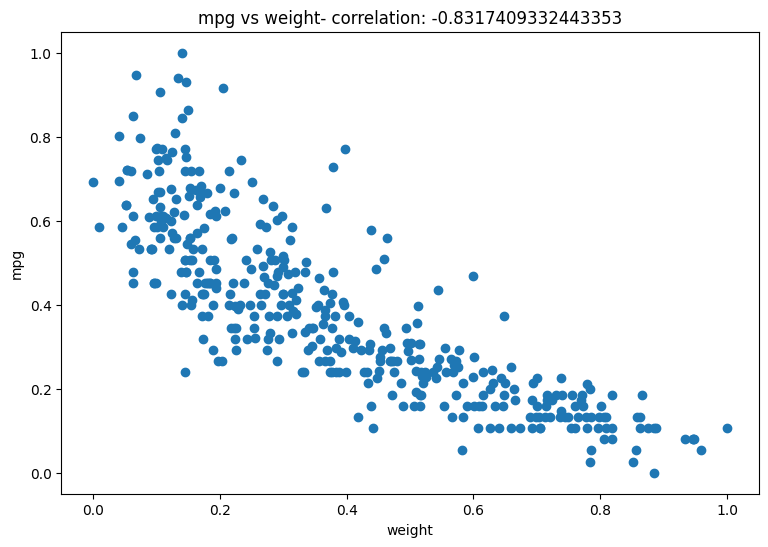

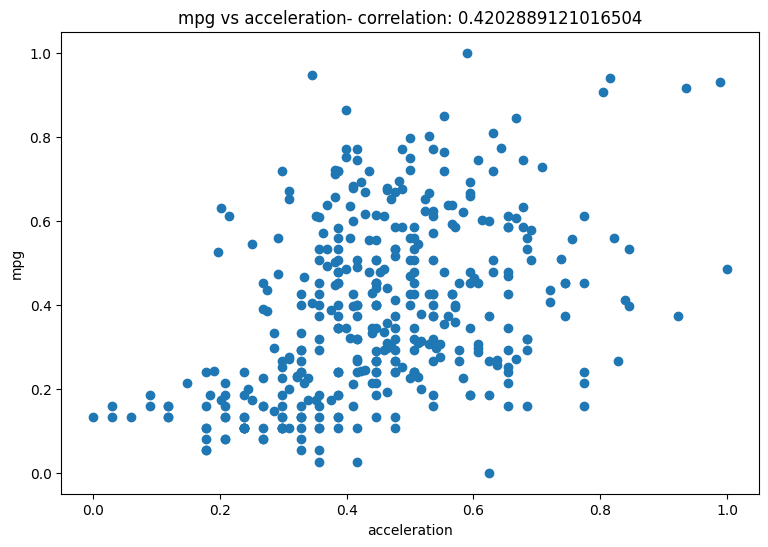

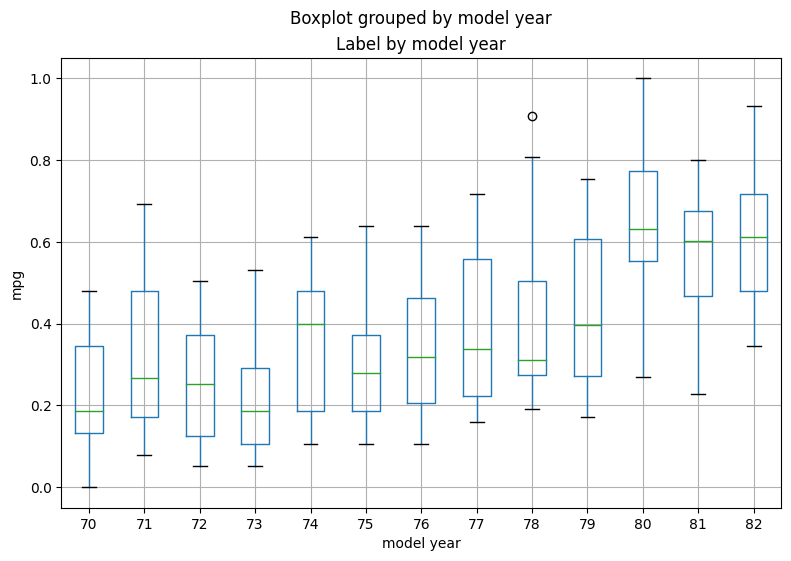

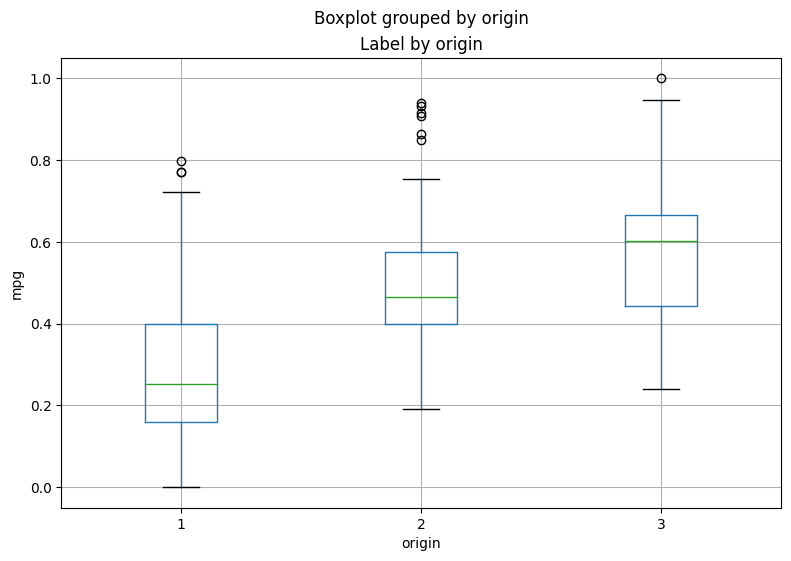

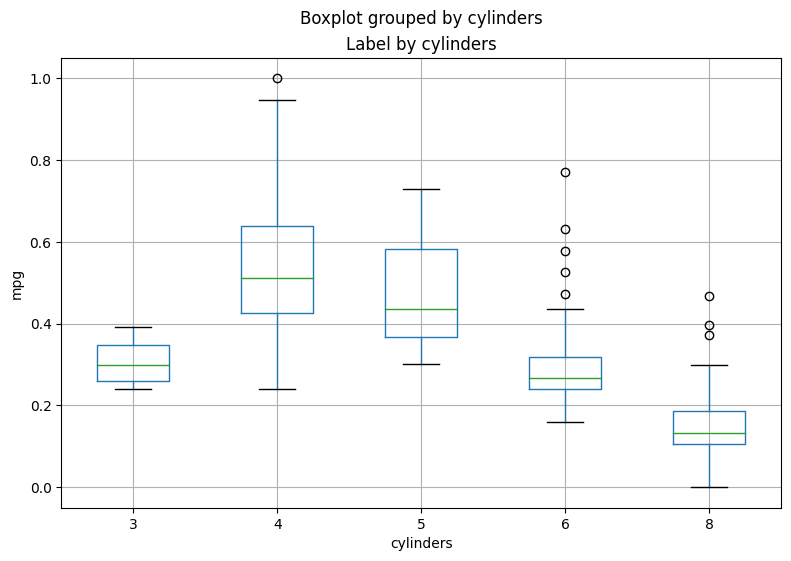

In [25]:
for col in nf:
    fig = mp.figure(figsize=(9, 6))
    ax = fig.gca()
    feature = df[col]
    label = df['mpg']
    correlation = feature.corr(label)
    mp.scatter(x=feature, y=label)
    mp.xlabel(col)
    mp.ylabel('mpg')
    ax.set_title('mpg vs ' + col + '- correlation: ' + str(correlation))
mp.show()
# plot a boxplot for the label by each categorical feature
for col in cf:
    fig = mp.figure(figsize=(9, 6))
    ax = fig.gca()
    df.boxplot(column = 'mpg', by = col, ax = ax)
    ax.set_title('Label by ' + col)
    ax.set_ylabel("mpg")
mp.show()

### Split Training and Test Data

Our data exploration is complete, now let's get back to action!
First, we need to separate out label and features-

In [26]:
x, y = df[['cylinders','acceleration','origin','model year','weight','displacement']].values, df['mpg'].values

Now let's split the data into two sets- Training set and Test set where training set will be bigger.

In [27]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.20)

print ('Training Set: %d rows\nTest Set: %d rows' % (x_train.shape[0], x_test.shape[0]))

Training Set: 318 rows
Test Set: 80 rows


***test_size*** attribute determines what %age of data to be left as test data, *0.20* means that 20% of data will be set as test data.

---

### Train and Evaluate the model

We're all set to train our first LinearRegression model.

In [28]:
from sklearn.linear_model import LinearRegression

model = LinearRegression().fit(x_train,y_train)
print(model)

LinearRegression()


#### Evaluation

Training of our regression model is complete, we can start evaluating it.

---

##### Testing the model

In [29]:
import numpy as np
predicted = model.predict(x_test)
np.set_printoptions(suppress=True)
print("Predictions: ", np.round(predicted)[ :10])
print("Reality: ", y_test[ :10])

Predictions:  [1. 1. 0. 0. 0. 0. 0. 1. 1. 0.]
Reality:  [0.55851064 0.43617021 0.15957447 0.30585106 0.18617021 0.29787234
 0.13297872 0.66755319 0.4787234  0.29255319]


It is veery tedious to look for every label if it is true or not, so we'll plot a graph for an overview of our model-

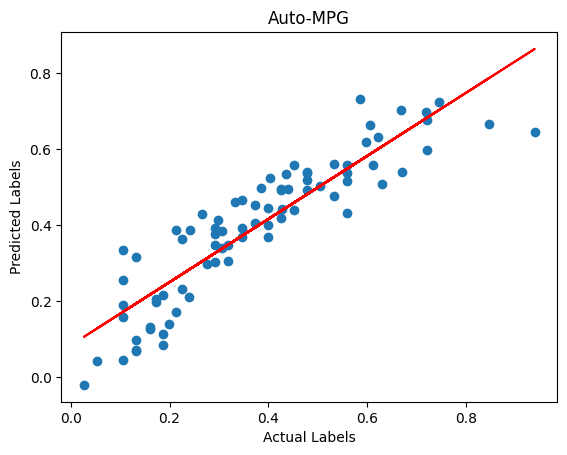

In [30]:
mp.scatter(y_test, predicted)
mp.xlabel('Actual Labels')
mp.ylabel('Predicted Labels')
mp.title('Auto-MPG')
# overlay the regression line
z = np.polyfit(y_test, predicted, 1)
p = np.poly1d(z)
mp.plot(y_test,p(y_test), color='red')
mp.show()

##### Finding RMSE, MSE and R2_Score

Testing of our model is complete, so we should check how good or bad our model performed. For this we'll use:-
1. **MSE**: the *mean-squared-error* shows a relative metric of our model. The smaller the value, the better the model.
2. **RMSE**: the *root-mean-squared-error* represents an average number of wrong predictions.
3. **R2_Score**: the *coefficient-of-determination* is a metric of how much variance the model is able to depict of our data.

In [31]:
from sklearn.metrics import mean_squared_error, r2_score
mse_1 = mean_squared_error(y_test,predicted)
rmse_1 = np.sqrt(mse_1)
r2_1 = r2_score(y_test,predicted)
print("MSE:{0}\nRMSE:{1}\nR2:{2}".format(mse_1,rmse_1,r2_1))

MSE:0.007908528269411562
RMSE:0.0889299064961364
R2:0.7993072996343927


### Trying different algorithms

Let's try these algorithms on our regression model - 

1. Linear Algorithms
2. Decision - Tree Algorithms
3. Ensemble Algorithms

Although only one algorithm is sufficient for a model, but in real world cases, it is hard to predict which algorithm is good for your model. So, we'll use evaluation of ***RMSE, MSE and R2_Score*** after each and every algorithm.

---

#### Linear Algorithms

Linear algorithms focus on finding collinearity between the dataset and using it to predict label values.

---

##### Lasso Algorithm

Lasso algorithm is useful when data has **sparse coefficients**(values that are close to zero), it reduces the dependency of data on its features.

Lasso()
MSE:0.013222000841184389
RMSE:0.11498695943968772
R2:0.6644686643762778


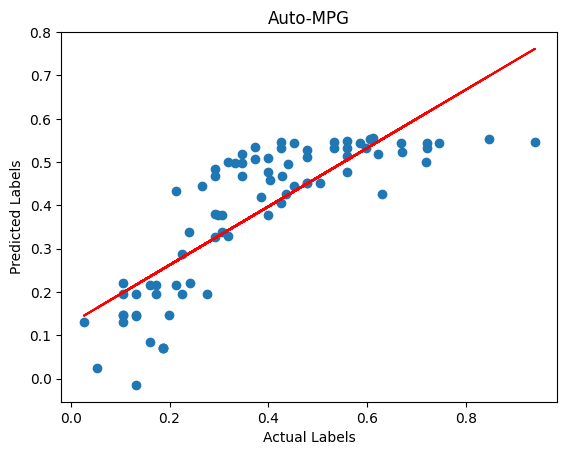

In [32]:
# Lasso Regression
from sklearn.linear_model import Lasso
model = Lasso().fit(x_train,y_train)
print(model)
predicted = model.predict(x_test)
# Model Evaluation
mse_2 = mean_squared_error(y_test,predicted)
rmse_2 = np.sqrt(mse_2)
r2_2 = r2_score(y_test,predicted)
print("MSE:{0}\nRMSE:{1}\nR2:{2}".format(mse_2,rmse_2,r2_2))
# Graph of predicted vs actual
mp.scatter(y_test, predicted)
mp.xlabel('Actual Labels')
mp.ylabel('Predicted Labels')
mp.title('Auto-MPG')
# overlay the regression line
z = np.polyfit(y_test, predicted, 1)
p = np.poly1d(z)
mp.plot(y_test,p(y_test), color='red')
mp.show()

##### Ridge Algorithm

Ridge algorithm is useful when the data is multi-dimensional or data has a high number of features on which it depends.

Ridge()
MSE:0.007637075560757239
RMSE:0.08739036308859942
R2:0.806195885634914


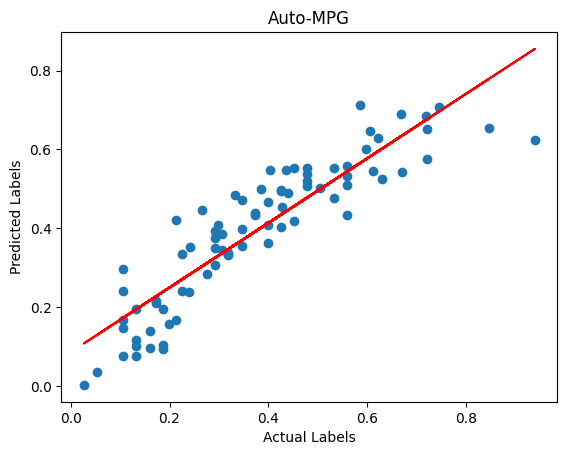

In [33]:
# Ridge Regression
from sklearn.linear_model import Ridge
model = Ridge().fit(x_train,y_train)
print(model)
predicted = model.predict(x_test)
# Model Evaluation
mse_3 = mean_squared_error(y_test,predicted)
rmse_3 = np.sqrt(mse_3)
r2_3 = r2_score(y_test,predicted)
print("MSE:{0}\nRMSE:{1}\nR2:{2}".format(mse_3,rmse_3,r2_3))
# Graph of predicted vs actual
mp.scatter(y_test, predicted)
mp.xlabel('Actual Labels')
mp.ylabel('Predicted Labels')
mp.title('Auto-MPG')
# overlay the regression line
z = np.polyfit(y_test, predicted, 1)
p = np.poly1d(z)
mp.plot(y_test,p(y_test), color='red')
mp.show()

#### Decision-Tree Algorithm

In a tree-based algorithm, Each branch is a feature value determined by the series of evaluations of each feature in hte dataset. Each branch contains predicted label values based on branch values in the form of leaf nodes.

DecisionTreeRegressor()
MSE:0.005105445761656858
RMSE:0.07145240207058723
R2:0.8704404079277196


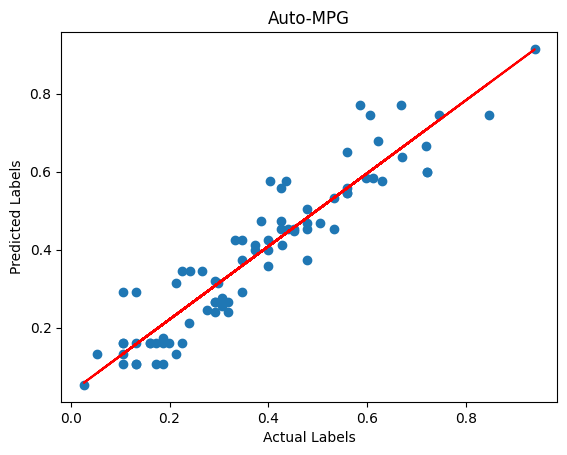

In [34]:
# Decision Tree Regression
from sklearn.tree import DecisionTreeRegressor
model = DecisionTreeRegressor().fit(x_train,y_train)
print(model)
predicted = model.predict(x_test)
# Model Evaluation
mse_4 = mean_squared_error(y_test,predicted)
rmse_4 = np.sqrt(mse_4)
r2_4 = r2_score(y_test,predicted)
print("MSE:{0}\nRMSE:{1}\nR2:{2}".format(mse_4,rmse_4,r2_4))
# Graph of predicted vs actual
mp.scatter(y_test, predicted)
mp.xlabel('Actual Labels')
mp.ylabel('Predicted Labels')
mp.title('Auto-MPG')
# overlay the regression line
z = np.polyfit(y_test, predicted, 1)
p = np.poly1d(z)
mp.plot(y_test,p(y_test), color='red')
mp.show()

#### Ensemble Algorithm

Ensemble algorithms work by combining multiple base models to produce a main model with a reduced error. It has two types:

| Bagging | Boosting |
| :------: | :------: |
| Apply average function to the results of the collection of the base models. | Build a sequence of base models on top of previous one to improve the predictive performance. |

Let's use **RandomForestRegressor** for *bagging* and **GradientBoosting** for *boosting* :-

RandomForestRegressor()
MSE:0.003331915715892369
RMSE:0.05772274868621875
R2:0.915446826560715


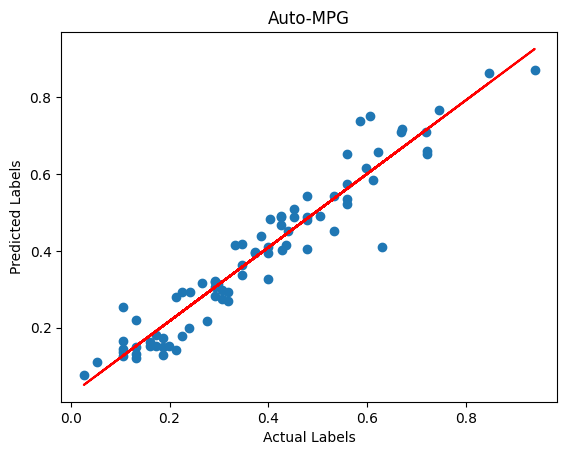

In [35]:
# Random Forest Regression
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor().fit(x_train,y_train)
print(model)
predicted = model.predict(x_test)
# Model Evaluation
mse_5 = mean_squared_error(y_test,predicted)
rmse_5 = np.sqrt(mse_5)
r2_5 = r2_score(y_test,predicted)
print("MSE:{0}\nRMSE:{1}\nR2:{2}".format(mse_5,rmse_5,r2_5))
# Graph of predicted vs actual
mp.scatter(y_test, predicted)
mp.xlabel('Actual Labels')
mp.ylabel('Predicted Labels')
mp.title('Auto-MPG')
# overlay the regression line
z = np.polyfit(y_test, predicted, 1)
p = np.poly1d(z)
mp.plot(y_test,p(y_test), color='red')
mp.show()

GradientBoostingRegressor()
MSE:0.003939943212493586
RMSE:0.06276896695416921
R2:0.900017068199553


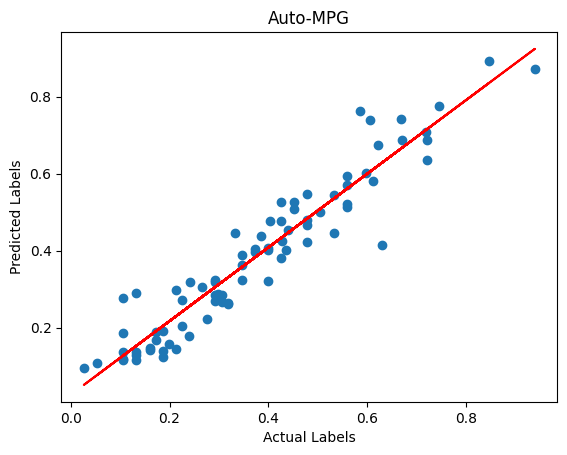

In [36]:
# Gradient Boosting Regression
from sklearn.ensemble import GradientBoostingRegressor
model = GradientBoostingRegressor().fit(x_train,y_train)
print(model)
predicted = model.predict(x_test)
# Model Evaluation
mse_6 = mean_squared_error(y_test,predicted)
rmse_6 = np.sqrt(mse_6)
r2_6 = r2_score(y_test,predicted)
print("MSE:{0}\nRMSE:{1}\nR2:{2}".format(mse_6,rmse_6,r2_6))
# Graph of predicted vs actual
mp.scatter(y_test, predicted)
mp.xlabel('Actual Labels')
mp.ylabel('Predicted Labels')
mp.title('Auto-MPG')
# overlay the regression line
z = np.polyfit(y_test, predicted, 1)
p = np.poly1d(z)
mp.plot(y_test,p(y_test), color='red')
mp.show()

By looking at the graph of **GradientBoosting** and **RandomForest**, we can see that it uses a number of parameters to train the model. What if we could change or provide the values of these parameters? 

---

### Optimizing Hyperparameters

A **Hyperparameter** is a value that you specify to change the behaviour of the regression model. They vary based upon the algorithm you use. Their optimization is important since they directly affect the performance and training time of the model.

Each algorithm has its specific type of hyperparameters and their tuning might result in a better predictive performance than that with default values. They can be viewed at [SKlearn documentation](https://scikit-learn.org/stable/user_guide.html).

Since we lack the **Deep Learning behind algorithms**, we'll have to experiment to correctly provide the values required to *tune* the hyperparameters.

**SKLearn** provides us a way of doing that by ***GridSearchCV***. It uses a grid of possible values and tries different combinations out of them.

> **Note:** There is a very less probablity that a *tuned* model will be significantly better than an *untuned* model.

Best parameters:  {'learning_rate': 0.01, 'n_estimators': 500}
Best Estimator  GradientBoostingRegressor(learning_rate=0.01, n_estimators=500)
MSE:0.0037395866203007305
RMSE:0.061152159571847754
R2:0.9051014662257646


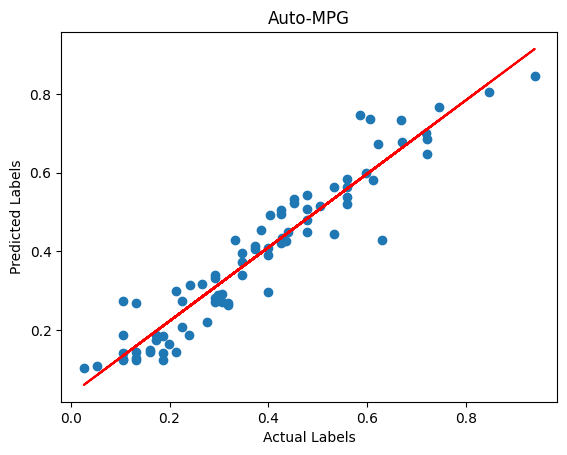

In [37]:
from sklearn.model_selection import GridSearchCV as gs
from sklearn.metrics import make_scorer as ms, r2_score as r2
alg = GradientBoostingRegressor()

parameters = {'learning_rate' : [0.01,0.05,0.1,0.5,1],
            'n_estimators' : [100,200,300,400,500]}
scorer = ms(r2)
grid_obj = gs(alg,parameters,scoring=scorer)
grid_obj.fit(x_train,y_train)
print("Best parameters: ",grid_obj.best_params_)

# best estimator
model = grid_obj.best_estimator_
print("Best Estimator ",model)
predicted = model.predict(x_test)
# Model Evaluation
mse_7 = mean_squared_error(y_test,predicted)
rmse_7 = np.sqrt(mse_7)
r2_7 = r2_score(y_test,predicted)
print("MSE:{0}\nRMSE:{1}\nR2:{2}".format(mse_7,rmse_7,r2_7))
# Graph of predicted vs actual
mp.scatter(y_test, predicted)
mp.xlabel('Actual Labels')
mp.ylabel('Predicted Labels')
mp.title('Auto-MPG')
# overlay the regression line
z = np.polyfit(y_test, predicted, 1)
p = np.poly1d(z)
mp.plot(y_test,p(y_test), color='red')
mp.show()

### Preprocessing Data

Our model is trained from data directly taken from the internet. But, in reality some preprocessing is always done before incorporating data into the model. We did some normalization of data above, but that was only for numeric data types. In preprocessing, we also encode categorical features into numeric datatypes, like:

| Size |
| :------: |
| S |
| M |
| L |

encoded to:

| Size |
| :------: |
| 0 |
| 1 |
| 2 |

In preprocessing, we also convert all numeric features to a same scale just as we did while normalizing it.

There is one other common technique used in preprocessing called ***One Hot Encoding*** in which individual binary is created for different columns.

| Size_S | Size_M | Size_L |
| :------: | :------: | :------: |
| 1 | 0 | 0 |
| 0 | 1 | 0 |
| 0 | 0 | 1 |

These preprocessing transformations can be applied using ***Pipelines*** feature of sklearn library. Pipelines enable us to define preprocessing steps from start and end with an algorithm.


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  [2, 4, 5]),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  [1, 3, 4])])),
                ('regressor', GradientBoostingRegressor())])
MSE:0.0049278717360855
RMSE:0.07019880152884023
R2:0.874946658584311


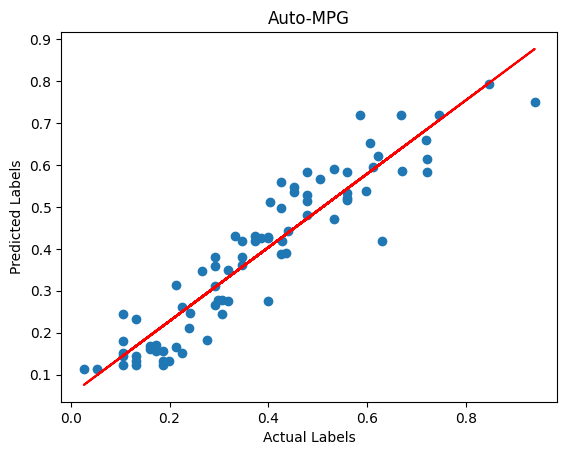

In [39]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import numpy as np

# Define preprocessing for numeric columns (scale them)
numeric_features = [2,4,5]
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())])

# Define preprocessing for categorical features (encode them)
categorical_features = [1,3,4]
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))])

# Combine preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)])

# Create preprocessing and training pipeline
pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                            ('regressor', GradientBoostingRegressor())]) # We used GradientBoostingRegressor here, you can use any other regressor

# fit the pipeline to train a linear regression model on the training set
model = pipeline.fit(x_train, y_train)
print (model)

# Evaluate the predictions on the test set
predicted = model.predict(x_test)
mse_8 = mean_squared_error(y_test,predicted)
rmse_8 = np.sqrt(mse_8)
r2_8 = r2_score(y_test,predicted)
print("MSE:{0}\nRMSE:{1}\nR2:{2}".format(mse_8,rmse_8,r2_8))
# Graph of predicted vs actual
mp.scatter(y_test, predicted)
mp.xlabel('Actual Labels')
mp.ylabel('Predicted Labels')
mp.title('Auto-MPG')
# overlay the regression line
z = np.polyfit(y_test, predicted, 1)
p = np.poly1d(z)
mp.plot(y_test,p(y_test), color='red')
mp.show()

We've used a number of algorithms on training a regression model. Let's see how each one performed:

| Algorithm | Mean Squared Error | Root Mean Squared Error | R2 Score |
| :------: | :------: | :------: | :------: |
| Ordinary Least Squares | 0.007908528269411562 | 0.0889299064961364 | 0.7993072996343927 |
| Lasso | 0.013222000841184389 | 0.11498695943968772 | 0.6644686643762778 |
| Ridge | 0.007637075560757239 | 0.08739036308859942 | 0.806195885634914 |
| Decision - Tree | 0.005105445761656858 | 0.07145240207058723 | 0.8704404079277196 |
| RandomForestRegressor | 0.003331915715892369 | 0.05772274868621875 | 0.915446826560715 |
| GradientBoosting | 0.003939943212493586 | 0.06276896695416921 | 0.900017068199553 |
| Tuned GradientBoosting | 0.0037395866203007305 | 0.061152159571847754 | 0.9051014662257646 |
| Preprocessed GradientBoosting | 0.0049278717360855 | 0.07019880152884023 | 0.874946658584311 |

### Using the Regression model

Let's now learn how to save and use this model.

---

#### Saving the model

We'll use **JOBLIB** library to save the model we just created.

In [41]:
import joblib as jb
jb.dump(model,'d:/Projects/ML/assets/autompg-model.pkl')

['d:/Projects/ML/assets/autompg-model.pkl']

#### Using Model

We can use our model wherever we require it.

In [43]:
load = jb.load('d:/Projects/ML/assets/autompg-model.pkl')

# Testing custom data
import numpy as np

# Define some data to score
x_new = np.array([[8,307,130,3504,12,70]])
print ('New sample: {}'.format(x_new))
res = load.predict(x_new)
print('Predicted MPG: {}'.format(res[0]))

New sample: [[   8  307  130 3504   12   70]]
Predicted MPG: 0.2941841799896086


🎉Woohoo!🎉 You've completed Training a Regression Model. 

---